<a href="https://colab.research.google.com/github/alixbattison/NMF_topicmodeling/blob/main/TopicModeling_NMF_forProteomics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Imports Cell
This cell imports all necessary libraries for the notebook, ensuring no library is imported more than once.

In [38]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import hashlib
import zipfile
import os
from google.colab import files
import joblib
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

METADATA_COLS = ['gene name'] # Changed to 'gene name' as per user request

## 2. File Upload and Validation Cell
This cell handles the upload of the Excel file and performs basic validation to ensure it's a valid Excel file.

In [39]:
uploaded = files.upload()
file_name = next(iter(uploaded))

if not file_name.endswith(('.xls', '.xlsx')):
    raise ValueError("Uploaded file must be an Excel file (.xls or .xlsx).")

print(f"File '{file_name}' uploaded successfully.")

Saving forTM_SILAC_EO771LatBControl_noduplicates.xlsx to forTM_SILAC_EO771LatBControl_noduplicates.xlsx
File 'forTM_SILAC_EO771LatBControl_noduplicates.xlsx' uploaded successfully.


## 3. Excel Loading and Raw Inspection Cell
This cell loads the uploaded Excel file into a pandas DataFrame and displays the first few rows for initial inspection.

In [40]:
raw_df = pd.read_excel(file_name)

# Rename 'Gene names' to 'gene name' if it exists to match METADATA_COLS
if 'Gene names' in raw_df.columns:
    raw_df.rename(columns={'Gene names': 'gene name'}, inplace=True)

if 'gene name' not in raw_df.columns:
    raise ValueError("The uploaded Excel file must contain a 'gene name' column.")

print("Raw data loaded. First 5 rows:")
display(raw_df.head())

Raw data loaded. First 5 rows:


,gene name,Intensity L Exp 1,Intensity H Exp 1,Intensity L Exp 2,Intensity H Exp 2,Intensity L Exp 3,Intensity H Exp 3,Intensity L LatB 1,Intensity H LatB 1,Intensity L LatB 2,Intensity H LatB 2,Intensity L LatB 3,Intensity H LatB 3
0,Abcb6,0,0,0,0,0,0,0,0,4174100,145020000,1597700,72428000
1,Acad9,0,63339000,7997800,241200000,9568500,339870000,0,0,5936900,209700000,14563000,115010000
2,Acadl,15202000,190710000,0,30339000,8697800,172820000,0,0,0,0,0,0
3,Acads,7985500,271300000,0,0,5066900,218200000,0,0,0,0,0,0
4,Acadvl,0,16189000,19671000,45642000,45479000,77880000,0,0,0,0,0,0


## 4. Column Parsing Cell
This cell extracts experimental groups and replicate numbers from the sample column headers using a regular expression, skipping the predefined metadata columns.

In [41]:
sample_columns = [col for col in raw_df.columns if col not in METADATA_COLS]

# Maps original column names to their condition (e.g., 'ConditionA_1' -> 'ConditionA')
condition_map = {}
# Maps original column names to their replicate number (e.g., 'ConditionA_1' -> 1)
replicate_map = {}

# A more general regex to capture conditions and replicates.
# This regex assumes the condition name is followed by an underscore and a digit(s) for replicates,
# or the entire name is the condition if no replicate number is found.
# Example: 'ConditionA_1', 'ConditionB_Rep2', 'ConditionC'
regex_condition_replicate = re.compile(r'^(.*?)[_-]?(\d+)$') # Captures 'ConditionA', '1' or 'ConditionB_Rep', '2'

for col in sample_columns:
    match = regex_condition_replicate.match(col)
    if match:
        # Group 1 is the condition part, Group 2 is the replicate number
        condition_raw = match.group(1).strip()
        replicate_num = int(match.group(2))

        # Clean up condition_raw: remove trailing underscores or 'Rep'
        condition = re.sub(r'[_-]?(Rep)?$', '', condition_raw, flags=re.IGNORECASE).strip()

        condition_map[col] = condition
        replicate_map[col] = replicate_num
    else:
        # If no explicit replicate number, treat the whole column name as the condition
        # and assign replicate 1 (or handle as a unique condition if it's not truly a replicate)
        condition_map[col] = col # Treat whole name as condition
        replicate_map[col] = 1 # Default replicate to 1
        warnings.warn(f"Could not extract replicate number from '{col}'. Treating as condition '{col}' and replicate 1.")

print("Sample columns parsed into experimental conditions and replicate numbers.")
print("Condition mapping (sample: condition):")
display(pd.Series(condition_map))
print("Replicate mapping (sample: replicate):")
display(pd.Series(replicate_map))

Sample columns parsed into experimental conditions and replicate numbers.
Condition mapping (sample: condition):


,0
Intensity L Exp 1,Intensity L Exp
Intensity H Exp 1,Intensity H Exp
Intensity L Exp 2,Intensity L Exp
Intensity H Exp 2,Intensity H Exp
Intensity L Exp 3,Intensity L Exp
Intensity H Exp 3,Intensity H Exp
Intensity L LatB 1,Intensity L LatB
Intensity H LatB 1,Intensity H LatB
Intensity L LatB 2,Intensity L LatB
Intensity H LatB 2,Intensity H LatB


Replicate mapping (sample: replicate):


,0
Intensity L Exp 1,1
Intensity H Exp 1,1
Intensity L Exp 2,2
Intensity H Exp 2,2
Intensity L Exp 3,3
Intensity H Exp 3,3
Intensity L LatB 1,1
Intensity H LatB 1,1
Intensity L LatB 2,2
Intensity H LatB 2,2


## 5. Sample Grouping Verification Cell
This cell prints a summary table of the identified experimental groups and their replicate counts, performing consistency checks.

In [42]:
group_counts = defaultdict(int)
for col, group in condition_map.items():
    group_counts[group] += 1

summary_df = pd.DataFrame({
    'Condition': list(group_counts.keys()),
    'Number of Replicates': list(group_counts.values())
})

print("Summary of Experimental Groups:")
display(summary_df)

# Consistency check: Ensure all identified replicates are unique within their condition
# This check needs access to replicate_map generated in the previous cell
for condition in set(condition_map.values()):
    replicates_in_condition = [replicate_map[s] for s, c in condition_map.items() if c == condition]
    if len(replicates_in_condition) != len(set(replicates_in_condition)):
        warnings.warn(f"Duplicate replicate numbers found for condition: {condition}")

print("Sample grouping verification complete. Check for any warnings about inconsistencies.")

Summary of Experimental Groups:


,Condition,Number of Replicates
0,Intensity L Exp,3
1,Intensity H Exp,3
2,Intensity L LatB,3
3,Intensity H LatB,3


Sample grouping verification complete. Check for any warnings about inconsistencies.


## 6. Raw Data Diagnostics Cell
This cell performs initial diagnostics on the raw data, such as checking for overall missing values and basic distributions.

Raw data diagnostics:
Missing values per column:


,0
Intensity L Exp 1,0
Intensity H Exp 1,0
Intensity L Exp 2,0
Intensity H Exp 2,0
Intensity L Exp 3,0
Intensity H Exp 3,0
Intensity L LatB 1,0
Intensity H LatB 1,0
Intensity L LatB 2,0
Intensity H LatB 2,0


Descriptive statistics for sample columns:


,Intensity L Exp 1,Intensity H Exp 1,Intensity L Exp 2,Intensity H Exp 2,Intensity L Exp 3,Intensity H Exp 3,Intensity L LatB 1,Intensity H LatB 1,Intensity L LatB 2,Intensity H LatB 2,Intensity L LatB 3,Intensity H LatB 3
count,4.990000e+02,4.990000e+02,4.990000e+02,4.990000e+02,4.990000e+02,4.990000e+02,499.0,499.0,4.990000e+02,4.990000e+02,4.990000e+02,4.990000e+02
mean,3.420025e+07,9.476182e+08,1.939988e+07,5.451170e+08,3.144902e+07,9.779234e+08,0.0,0.0,4.524679e+06,1.642443e+08,2.628418e+06,1.047519e+08
std,7.003075e+07,1.578796e+09,4.419221e+07,9.651873e+08,5.281821e+07,1.526003e+09,0.0,0.0,1.828242e+07,5.053671e+08,1.012264e+07,4.061711e+08
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,9.016950e+07,0.000000e+00,3.542500e+07,4.067050e+06,1.186500e+08,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.378800e+07,4.524500e+08,6.305900e+06,2.072300e+08,1.499600e+07,4.411100e+08,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.441350e+07,1.176550e+09,1.863100e+07,7.080000e+08,3.673100e+07,1.312900e+09,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.540800e+08,1.579700e+10,3.547200e+08,1.042400e+10,4.523900e+08,1.616600e+10,0.0,0.0,2.716700e+08,5.722000e+09,1.338200e+08,6.602800e+09


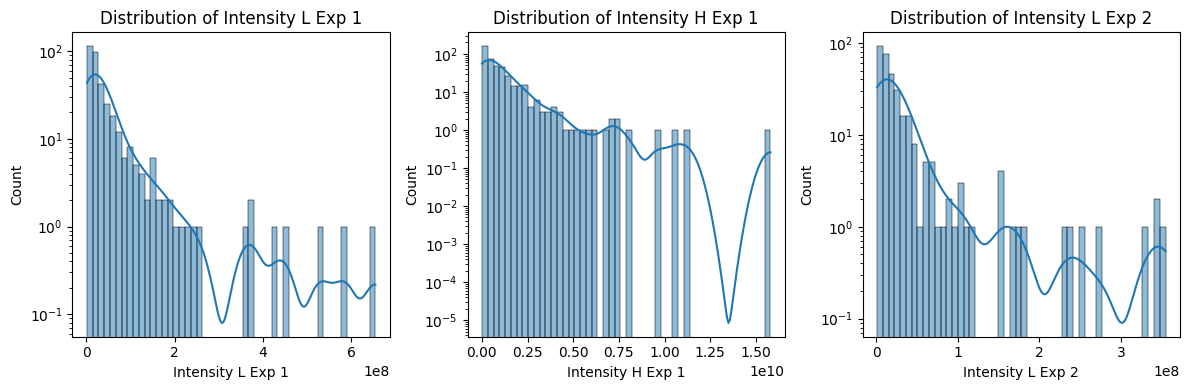

In [43]:
print("Raw data diagnostics:")
print("Missing values per column:")
display(raw_df[sample_columns].isnull().sum())

# Basic descriptive statistics for sample columns
print("Descriptive statistics for sample columns:")
display(raw_df[sample_columns].describe())

# Visualize distribution of non-zero values for a few samples
fig, axes = plt.subplots(1, min(3, len(sample_columns)), figsize=(12, 4)) # Resized from (15, 5)
if len(sample_columns) > 0:
    if len(sample_columns) == 1:
        axes = [axes]
    for i, col in enumerate(sample_columns[:min(3, len(sample_columns))]):
        sns.histplot(raw_df[col][raw_df[col] > 0], bins=50, kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_yscale('log') # Log scale for intensity often useful
    plt.tight_layout()
    plt.show()
else:
    print("No sample columns to diagnose.")

## 7. CTM Input Matrix Construction Cell
This cell transforms the data by transposing it so rows are samples and columns are compounds, and adds the extracted condition and replicate metadata.

In [44]:
ctm_input = raw_df[sample_columns].T # Transpose sample data

# Create unique gene names to avoid duplicate column issues
# This handles cases where 'gene name' might not be unique in the original data
unique_gene_names = []
name_counts = defaultdict(int)
for name in raw_df['gene name']:
    if name_counts[name] > 0:
        unique_gene_names.append(f"{name}_{name_counts[name]}")
    else:
        unique_gene_names.append(name)
    name_counts[name] += 1
ctm_input.columns = unique_gene_names

# Add condition and replicate columns for initial grouping
ctm_input['condition'] = ctm_input.index.map(condition_map)
ctm_input['replicate'] = ctm_input.index.map(replicate_map)

# Aggregate replicate data by calculating the mean for each condition
# The index of the aggregated_ctm will be the unique conditions.
aggregated_ctm = ctm_input.groupby('condition').mean()

print("CTM input matrix constructed and replicates aggregated. First 5 rows and last 5 columns:")
display(aggregated_ctm.head())

CTM input matrix constructed and replicates aggregated. First 5 rows and last 5 columns:


,Abcb6,Acad9,Acadl,Acads,Acadvl,Acat1,Acly,Aco2,Acot7,Actb;Actg1,...,Vim;Nefm;Ina;Nefl,Vma21,Xrn2,Yme1l1,Ywhab,Ywhae,Ywhag,Ywhaq,Ywhaz,replicate
condition,,,,,,,,,,,,,,,,,,,,,
Intensity H Exp,0.000000e+00,2.148030e+08,1.312897e+08,1.631667e+08,4.657033e+07,5.372133e+08,6.140333e+07,8.452133e+08,2.872190e+08,1.595803e+09,...,4.448660e+09,2.042733e+08,1.480467e+08,7.081067e+07,5.684033e+08,1.060000e+09,1.332603e+09,8.544830e+08,1.219833e+09,2.0
Intensity H LatB,7.248267e+07,1.082367e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.760167e+08,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.0
Intensity L Exp,0.000000e+00,5.855433e+06,7.966600e+06,4.350800e+06,2.171667e+07,1.200833e+07,1.994833e+07,1.335100e+07,2.490133e+06,3.106300e+07,...,1.342000e+08,2.941533e+07,2.941033e+07,2.092633e+06,1.320903e+07,2.874833e+07,3.246800e+07,1.058407e+07,4.312600e+07,2.0
Intensity L LatB,1.923933e+06,6.833300e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.807067e+06,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.0


## 8. Within-group Missing Value Imputation Cell
This cell imputes missing values (zeros) based on within-group statistics: half the within-group minimum if partially detected, or global_min/5 if never detected in a group.

In [45]:
# Replace 0 with NaN for imputation logic
ctm_input_imputed = aggregated_ctm.replace(0, np.nan).copy()

# Define feature columns after conversion. These are now the gene names.
feature_cols = ctm_input_imputed.columns # All columns are now features (gene names)

global_min = ctm_input_imputed[feature_cols].min().min()
if pd.isna(global_min) or global_min == 0:
    # If global min is 0 or NaN (e.g., all values are 0 or NaN), we need a fallback.
    print("Warning: Global minimum is 0 or NaN. Using a small fixed value for imputation where necessary.")
    global_min_fallback = 1e-6 # A very small positive number
else:
    global_min_fallback = global_min

# Imputation loop iterates through each feature (gene)
for feature in feature_cols:
    for condition_name in ctm_input_imputed.index: # Iterate through each condition (row index)
        # Get the value for the current feature and condition
        value = ctm_input_imputed.loc[condition_name, feature]

        if pd.isna(value): # Only impute if the value is NaN
            # Calculate within-group minimum of *detected* values for this feature across all conditions
            # Or, if we are strictly imputing 'within-group' for a particular missing value, we need to decide what 'group' means now.
            # Since we have already aggregated, a 'group' here is effectively just the single condition's data point.
            # If it's NaN after aggregation, it means all replicates for that condition were 0 or NaN.

            # We'll use the fallback global_min_fallback / 5.0 for missing values after aggregation
            imputation_value = global_min_fallback / 5.0
            ctm_input_imputed.loc[condition_name, feature] = imputation_value

assert not ctm_input_imputed[feature_cols].isnull().any().any(), "NaNs still present after imputation!"
assert not (ctm_input_imputed[feature_cols] == 0).any().any(), "Zeros still present after imputation!"

print("Missing values imputed. Displaying head of imputed matrix:")
display(ctm_input_imputed.head())

# CRITICAL: Define feature_cols here after imputation and before NMF
feature_cols = ctm_input_imputed.columns # These are the gene names

Missing values imputed. Displaying head of imputed matrix:


,Abcb6,Acad9,Acadl,Acads,Acadvl,Acat1,Acly,Aco2,Acot7,Actb;Actg1,...,Vim;Nefm;Ina;Nefl,Vma21,Xrn2,Yme1l1,Ywhab,Ywhae,Ywhag,Ywhaq,Ywhaz,replicate
condition,,,,,,,,,,,,,,,,,,,,,
Intensity H Exp,4.000000e-01,2.148030e+08,1.312897e+08,1.631667e+08,4.657033e+07,5.372133e+08,6.140333e+07,8.452133e+08,2.872190e+08,1.595803e+09,...,4.448660e+09,2.042733e+08,1.480467e+08,7.081067e+07,5.684033e+08,1.060000e+09,1.332603e+09,8.544830e+08,1.219833e+09,2.0
Intensity H LatB,7.248267e+07,1.082367e+08,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,2.760167e+08,4.000000e-01,4.000000e-01,...,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,2.0
Intensity L Exp,4.000000e-01,5.855433e+06,7.966600e+06,4.350800e+06,2.171667e+07,1.200833e+07,1.994833e+07,1.335100e+07,2.490133e+06,3.106300e+07,...,1.342000e+08,2.941533e+07,2.941033e+07,2.092633e+06,1.320903e+07,2.874833e+07,3.246800e+07,1.058407e+07,4.312600e+07,2.0
Intensity L LatB,1.923933e+06,6.833300e+06,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,2.807067e+06,4.000000e-01,4.000000e-01,...,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,4.000000e-01,2.0


## 9. Data Fingerprint Verification Cell
This cell generates a unique hash (fingerprint) of the processed data to ensure reproducibility and detect any unintended changes.

In [46]:
data_hash = hashlib.sha256(pd.util.hash_pandas_object(ctm_input_imputed[feature_cols], index=True).values).hexdigest()
print(f"Data fingerprint (SHA256 hash): {data_hash}")

Data fingerprint (SHA256 hash): 26c343fe30ac79cc8ae86918767d68103a38925234c2b791cbb152fd696223da


In [47]:
output_dir = 'nmf_results'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory '{output_dir}' ensured.")

Output directory 'nmf_results' ensured.


## 10. Elbow Plot Cell
This cell performs NMF with varying numbers of components (from 2 to min(10, N-1)), calculates the Frobenius norm reconstruction error, and plots it to help determine the optimal number of components. The plot is saved as a PNG.

Calculating NMF reconstruction errors for elbow plot...


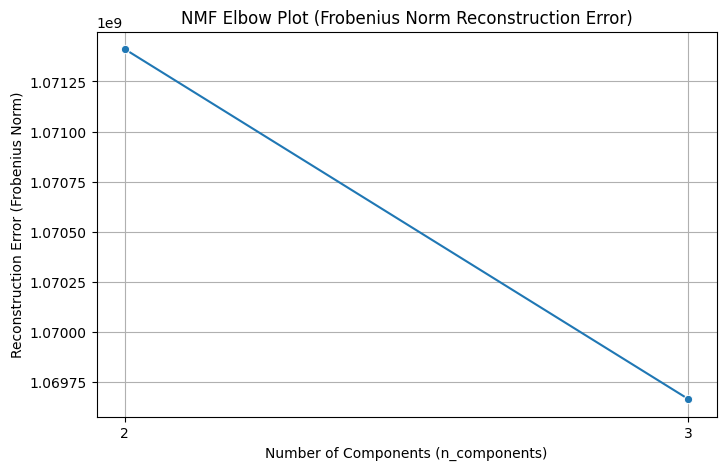

Elbow plot saved as nmf_elbow_plot.png


In [48]:
X = ctm_input_imputed[feature_cols].values

# Ensure X contains only non-negative values for NMF
if (X < 0).any():
    warnings.warn("NMF input matrix contains negative values. NMF expects non-negative input.")
    # For this exercise, we'll proceed assuming values are positive due to imputation strategy.
    # In a real scenario, consider min-max scaling to [0,1] or other transformations.

# Scale data for NMF if desired (NMF works on raw counts, but scaling can sometimes help)
# For this problem, we stick to the NMF's expectation of non-negative values after imputation.
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# Determine max components based on data dimensions
max_components = min(10, X.shape[0] - 1, X.shape[1] - 1)
if max_components < 2:
    raise ValueError("Not enough samples or features to perform NMF with at least 2 components.")

n_components_range = range(2, max_components + 1)
reconstruction_errors = []

print("Calculating NMF reconstruction errors for elbow plot...")
for n in n_components_range:
    model = NMF(n_components=n, init='random', random_state=42, max_iter=2000, tol=1e-4)
    W = model.fit_transform(X)
    H = model.components_
    reconstruction_error = model.reconstruction_err_
    reconstruction_errors.append(reconstruction_error)

plt.figure(figsize=(8, 5)) # Resized from (10, 6)
sns.lineplot(x=list(n_components_range), y=reconstruction_errors, marker='o')
plt.title('NMF Elbow Plot (Frobenius Norm Reconstruction Error)')
plt.xlabel('Number of Components (n_components)')
plt.ylabel('Reconstruction Error (Frobenius Norm)')
plt.xticks(list(n_components_range))
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'nmf_elbow_plot.png')) # Save elbow plot
plt.show()
print("Elbow plot saved as nmf_elbow_plot.png")

## 17. Silhouette Plot Cell
This cell generates a silhouette plot to help determine the optimal number of NMF components. It calculates the silhouette score for each `n_components` by assigning each sample to the NMF component to which it contributes most.

Calculating NMF silhouette scores...


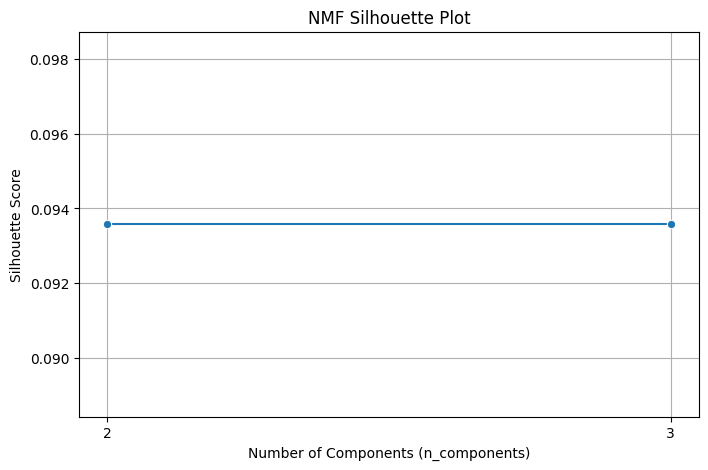

Silhouette plot saved as nmf_silhouette_plot.png


In [49]:
from sklearn.metrics import silhouette_score

# Re-use X from previous NMF calculations
X_silhouette = ctm_input_imputed[feature_cols].values

silhouette_scores = []

print("Calculating NMF silhouette scores...")
# Use the same range of components as the elbow plot
# Determine max components based on data dimensions
max_components_silhouette = min(10, X_silhouette.shape[0] - 1, X_silhouette.shape[1] - 1)
if max_components_silhouette < 2:
    raise ValueError("Not enough samples or features to perform NMF with at least 2 components for silhouette analysis.")
n_components_range_silhouette = range(2, max_components_silhouette + 1)

for n in n_components_range_silhouette:
    model_silhouette = NMF(n_components=n, init='random', random_state=42, max_iter=2000, tol=1e-4)
    W_silhouette = model_silhouette.fit_transform(X_silhouette)

    # Assign each sample to the component with the highest contribution
    # This creates discrete clusters required for silhouette_score
    labels = np.argmax(W_silhouette, axis=1)

    if len(np.unique(labels)) > 1: # Silhouette score requires at least 2 clusters
        score = silhouette_score(X_silhouette, labels)
        silhouette_scores.append(score)
    else:
        # If only one 'cluster' is formed (e.g., all samples assigned to Component 1),
        # silhouette score is undefined. Assign NaN or a very low value.
        silhouette_scores.append(np.nan)
        warnings.warn(f"Only one component was dominant for n_components={n}. Silhouette score is undefined.")

plt.figure(figsize=(8, 5))
sns.lineplot(x=list(n_components_range_silhouette), y=silhouette_scores, marker='o')
plt.title('NMF Silhouette Plot')
plt.xlabel('Number of Components (n_components)')
plt.ylabel('Silhouette Score')
plt.xticks(list(n_components_range_silhouette))
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'nmf_silhouette_plot.png')) # Save silhouette plot
plt.show()
print("Silhouette plot saved as nmf_silhouette_plot.png")

## 11. Optimal n_components Setting Cell
This cell allows the user to manually set the `optimal_n_components` value after reviewing the elbow plot.

In [50]:
optimal_n_components = 3 # Adjust this value after inspecting the elbow plot

## 12. NMF Training Cell
This cell fits the NMF model with the chosen optimal number of components, extracts the W and H matrices, constructs several NMF-related dataframes, computes component correlations, and saves all results to PKL and XLSX files.

In [51]:
nmf_model = NMF(n_components=optimal_n_components, init='random', random_state=42, max_iter=2000, tol=1e-4)

# X is now the imputed and aggregated data where rows are conditions and columns are gene names
W = nmf_model.fit_transform(X)
H = nmf_model.components_

# doc_component_df (W matrix with condition metadata)
doc_component_df = pd.DataFrame(W, index=ctm_input_imputed.index, columns=[f'Component_{i+1}' for i in range(optimal_n_components)])
doc_component_df.index.name = 'condition' # Name the index as 'condition'

# component_feature_probs_df (H matrix normalized to sum to 1 across features for each component)
component_feature_probs_df = pd.DataFrame(H, index=[f'Component_{i+1}' for i in range(optimal_n_components)], columns=feature_cols)
component_feature_probs_df = component_feature_probs_df.apply(lambda x: x / x.sum(), axis=1) # Normalize rows to sum to 1

# component_feature_df (H matrix for top features)
# For top 50 features per component, or all if less than 50
component_feature_list = [] # Collect DataFrames here
for i in range(optimal_n_components):
    component_contrib = pd.Series(H[i], index=feature_cols)
    top_features = component_contrib.nlargest(min(50, len(feature_cols))) # min(50, number of genes)
    for feature, contribution in top_features.items():
        component_feature_list.append({'Component': f'Component_{i+1}', 'Feature': feature, 'Contribution': contribution})
component_feature_df = pd.DataFrame(component_feature_list) # Concatenate once at the end

# component_correlation_df (correlation between components based on feature contributions)
component_correlation_df = component_feature_probs_df.T.corr()

print("NMF training complete. Displaying head of doc_component_df:")
display(doc_component_df.head())
print("Displaying head of component_feature_probs_df:")
display(component_feature_probs_df.head())
print("Displaying head of component_feature_df:")
display(component_feature_df.head())
print("Displaying component_correlation_df:")
display(component_correlation_df)

# Save results
output_dir = 'nmf_results'

# --- MODIFICATION START --- # Ensuring clean slate
if os.path.exists(output_dir):
    import shutil
    shutil.rmtree(output_dir)
# --- MODIFICATION END ---

os.makedirs(output_dir, exist_ok=True)

joblib.dump(nmf_model, os.path.join(output_dir, 'nmf_model.pkl'))
joblib.dump(W, os.path.join(output_dir, 'W_matrix.pkl'))
joblib.dump(H, os.path.join(output_dir, 'H_matrix.pkl'))
doc_component_df.to_pickle(os.path.join(output_dir, 'doc_component_df.pkl'))
component_feature_probs_df.to_pickle(os.path.join(output_dir, 'component_feature_probs_df.pkl'))
component_feature_df.to_pickle(os.path.join(output_dir, 'component_feature_df.pkl'))
component_correlation_df.to_pickle(os.path.join(output_dir, 'component_correlation_df.pkl'))

# Save to Excel
with pd.ExcelWriter(os.path.join(output_dir, 'nmf_results.xlsx')) as writer:
    doc_component_df.to_excel(writer, sheet_name='DocComponent', index=True)
    component_feature_probs_df.to_excel(writer, sheet_name='ComponentFeatureProbs', index=True)
    component_feature_df.to_excel(writer, sheet_name='ComponentFeatureTop', index=False)
    component_correlation_df.to_excel(writer, sheet_name='ComponentCorrelation', index=True)

print(f"NMF results saved to '{output_dir}' directory.")

NMF training complete. Displaying head of doc_component_df:


,Component_1,Component_2,Component_3
condition,,,
Intensity H Exp,70290.662793,14474.964037,25.478927
Intensity H LatB,0.000000,12741.692886,21191.906081
Intensity L Exp,1582.606006,0.000000,59.281795
Intensity L LatB,11.120466,0.000000,431.744207


Displaying head of component_feature_probs_df:


,Abcb6,Acad9,Acadl,Acads,Acadvl,Acat1,Acly,Aco2,Acot7,Actb;Actg1,...,Vim;Nefm;Ina;Nefl,Vma21,Xrn2,Yme1l1,Ywhab,Ywhae,Ywhag,Ywhaq,Ywhaz,replicate
Component_1,0.000000,0.000507,3.273119e-04,4.064719e-04,0.000117,1.338117e-03,0.000154,0.001846,0.000715,0.003974,...,0.011083,0.000510,0.000370,1.764111e-04,0.001416,2.640641e-03,3.319537e-03,0.002127,0.003039,5.085740e-12
Component_2,0.000000,0.001144,0.000000e+00,0.000000e+00,0.000000,8.081477e-07,0.000000,0.010841,0.000012,0.000015,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000026,0.000000,0.000000e+00
Component_3,0.001993,0.002713,3.696450e-07,3.707816e-08,0.000002,0.000000e+00,0.000001,0.005076,0.000000,0.000000,...,0.000002,0.000002,0.000002,3.165690e-08,0.000000,2.776183e-07,6.947991e-08,0.000000,0.000001,5.623112e-11


Displaying head of component_feature_df:


,Component,Feature,Contribution
0,Component_1,Eef1a1;Eef1a2,201029.997199
1,Component_1,Hsp90aa1;Hsp90ab1,129393.974346
2,Component_1,S100a6,123974.437321
3,Component_1,Gapdh;Gm3839,80314.344648
4,Component_1,Tsnax,77772.823926


Displaying component_correlation_df:


,Component_1,Component_2,Component_3
Component_1,1.000000,0.328542,0.135868
Component_2,0.328542,1.000000,0.779065
Component_3,0.135868,0.779065,1.000000


NMF results saved to 'nmf_results' directory.


## 13. Heatmap - Individual Sample Component Contributions Cell
This cell generates a clustermap visualizing the contribution of each NMF component to individual samples, colored by experimental condition.

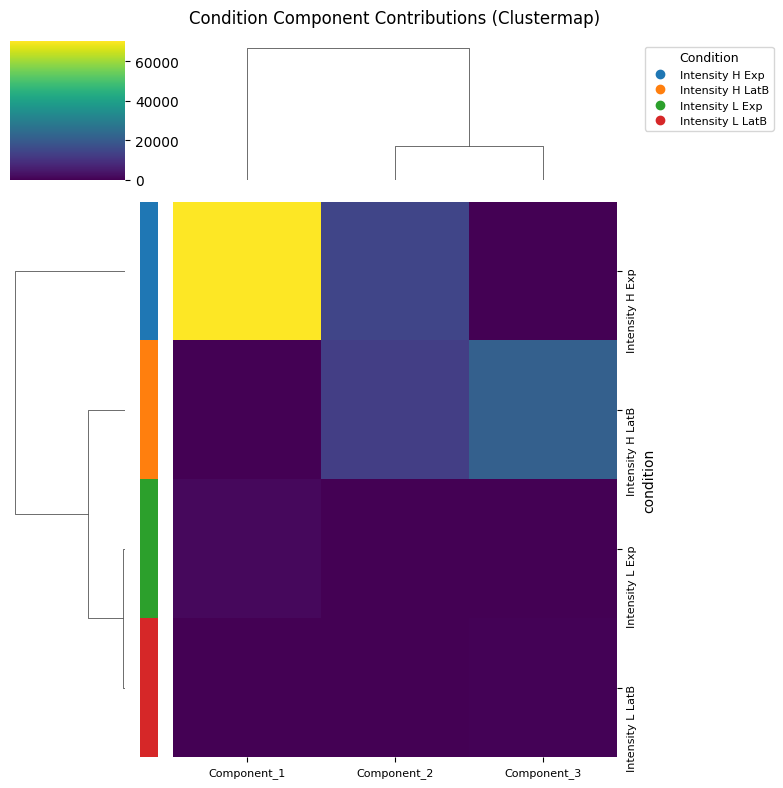

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# doc_component_df now has conditions as its index
doc_component_matrix = doc_component_df # It already contains only component contributions

# Create a color mapping for conditions
condition_colors = sns.color_palette('tab10', n_colors=len(doc_component_df.index.unique()))
condition_lut = dict(zip(doc_component_df.index.unique(), condition_colors))
row_colors = doc_component_df.index.map(condition_lut)

# Create the clustermap
g = sns.clustermap(
    doc_component_matrix,
    cmap='viridis',
    row_colors=row_colors,
    cbar_pos=(0.02, 0.8, 0.03, 0.18),
    col_cluster=True,
    row_cluster=True, # Clustering rows (conditions) is appropriate now
    yticklabels=doc_component_df.index.tolist() # Use conditions as y-tick labels
)
g.fig.suptitle('Condition Component Contributions (Clustermap)', fontsize=12)

# Adjust the figure size of the clustermap
g.fig.set_size_inches(8, 8)

# Adjust font sizes for tick labels on the heatmap
g.ax_heatmap.tick_params(axis='y', labelsize=8)
g.ax_heatmap.tick_params(axis='x', labelsize=8)

# Create a legend for the row colors and attach it to the clustermap figure
handles = [plt.Line2D([0], [0], color=v, marker='o', linestyle='') for k, v in condition_lut.items()]
g.ax_col_dendrogram.legend(handles, condition_lut.keys(), title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 8}, title_fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'clustermap_condition_contributions.png')) # Save clustermap
plt.show()

## 14. Heatmap - Average Component Contributions per Condition Cell
This cell visualizes the average contribution of each NMF component per experimental condition, with contributions normalized such that each row (condition) sums to 1.

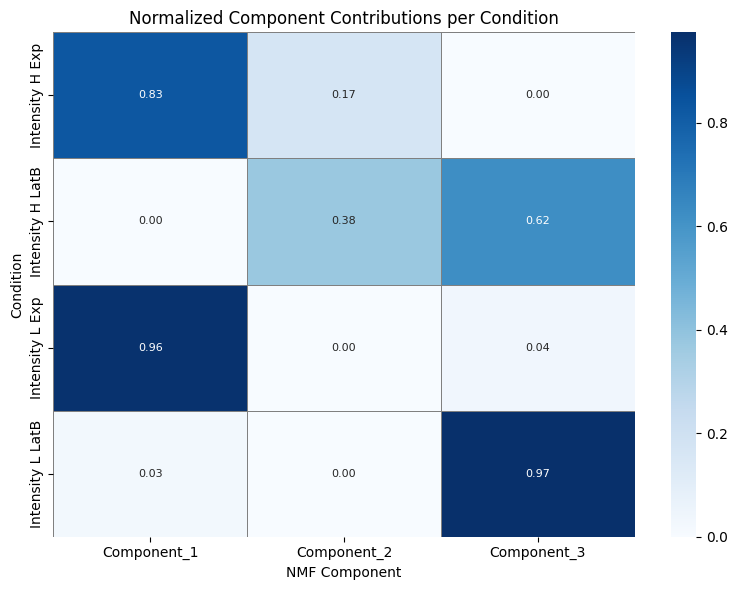

In [53]:
component_columns = [col for col in doc_component_df.columns if col.startswith('Component_')]

# doc_component_df already has conditions as its index, and values are direct component contributions.
# No need for groupby().mean() or separate condition/replicate columns here. Each row IS a condition.
# The current doc_component_df is already the 'average component contribution per condition' effectively
# if the NMF was run on aggregated data.

# To visualize the *relative* contribution, we normalize each row to sum to 1.
average_component_contrib_normalized = doc_component_df[component_columns].div(doc_component_df[component_columns].sum(axis=1), axis=0)

plt.figure(figsize=(8, 6))
sns.heatmap(average_component_contrib_normalized, cmap='Blues', annot=True, fmt=".2f", linewidths=.5, linecolor='gray', annot_kws={'fontsize': 8})
plt.title('Normalized Component Contributions per Condition', fontsize=12)
plt.xlabel('NMF Component', fontsize=10)
plt.ylabel('Condition', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'heatmap_normalized_condition_contributions.png')) # Save heatmap
plt.show()

## 15. Bar Graphs - Top 25 Metabolites per Component Cell
This cell generates a series of bar graphs, each showing the top 25 contributing metabolites for a specific NMF component.

/tmp/ipykernel_2305/1099637958.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contribution', y='Feature', data=top_metabolites.sort_values('Contribution', ascending=False), palette='viridis')


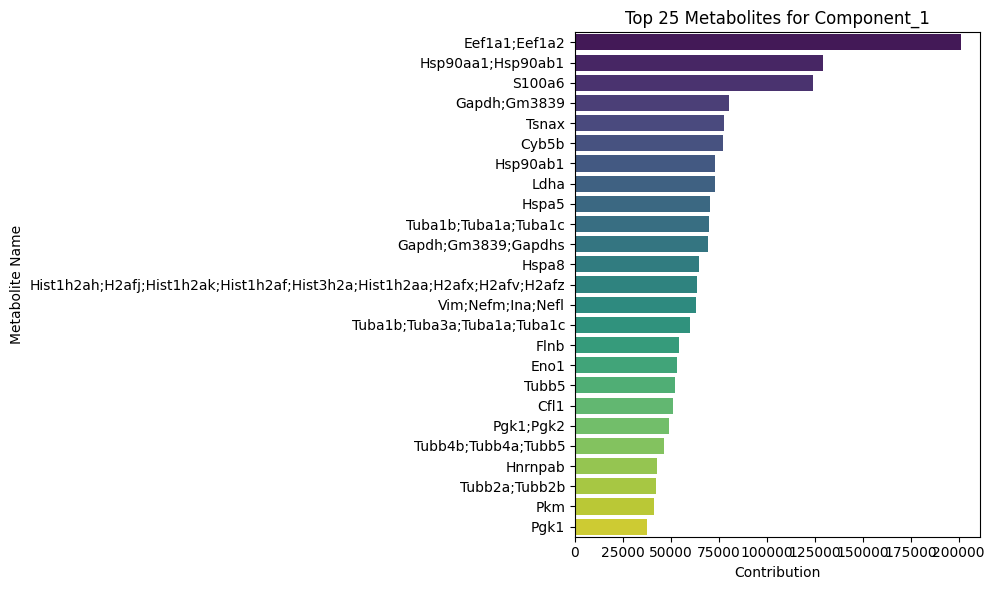

/tmp/ipykernel_2305/1099637958.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contribution', y='Feature', data=top_metabolites.sort_values('Contribution', ascending=False), palette='viridis')


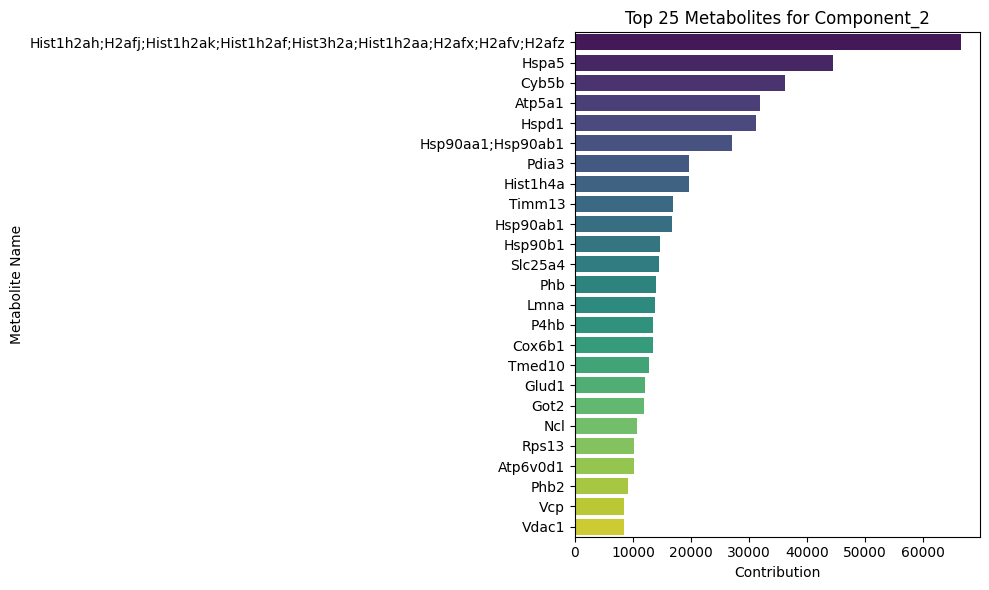

/tmp/ipykernel_2305/1099637958.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contribution', y='Feature', data=top_metabolites.sort_values('Contribution', ascending=False), palette='viridis')


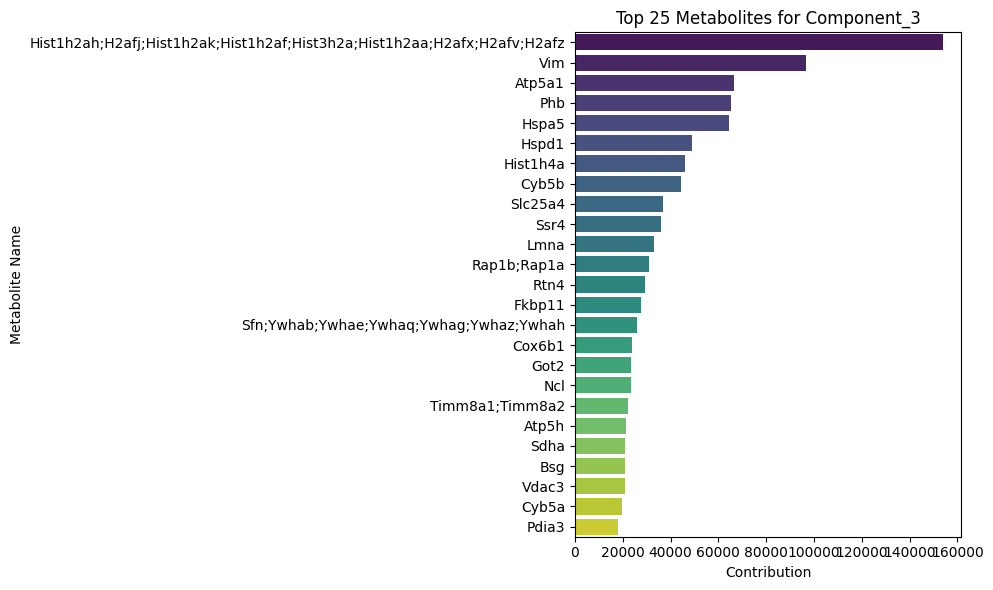

In [54]:
for i in range(optimal_n_components):
    component_name = f'Component_{i+1}'
    top_metabolites = component_feature_df[component_feature_df['Component'] == component_name].nlargest(25, 'Contribution')

    if not top_metabolites.empty:
        plt.figure(figsize=(10, 6)) # Resized from (12, 7)
        sns.barplot(x='Contribution', y='Feature', data=top_metabolites.sort_values('Contribution', ascending=False), palette='viridis')
        plt.title(f'Top 25 Metabolites for {component_name}')
        plt.xlabel('Contribution')
        plt.ylabel('Metabolite Name')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f'bar_graph_top_metabolites_{component_name}.png')) # Save bar graph
        plt.show()
    else:
        print(f"No top metabolites found for {component_name} (this should not happen if component_feature_df is built correctly).")

## 16. Correlation Matrix Cell
This cell displays side-by-side heatmaps of the NMF component correlation matrix and the empirical correlation matrix derived from the `doc_component_df` (W matrix).

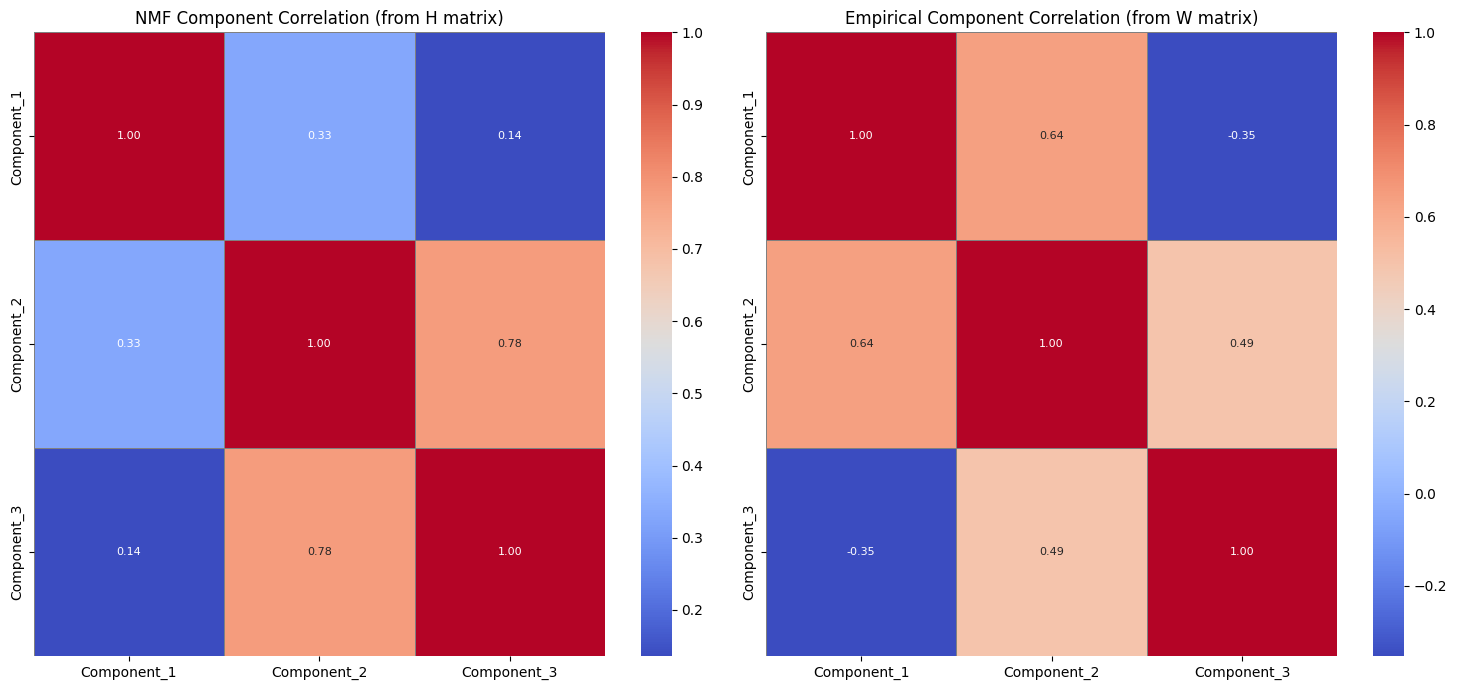

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7)) # Resized from (18, 8)

# Heatmap 1: Component correlation from H matrix
sns.heatmap(component_correlation_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='gray', ax=axes[0], annot_kws={'fontsize': 8}) # Adjusted annotation font size
axes[0].set_title('NMF Component Correlation (from H matrix)', fontsize=12) # Adjusted title font size

# Heatmap 2: Empirical correlation from W matrix
empirical_correlation_df = doc_component_df.corr()
sns.heatmap(empirical_correlation_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='gray', ax=axes[1], annot_kws={'fontsize': 8}) # Adjusted annotation font size
axes[1].set_title('Empirical Component Correlation (from W matrix)', fontsize=12) # Adjusted title font size

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'heatmap_component_correlations.png')) # Save combined heatmap
plt.show()

## 17. Determinism Verification Cell
This cell reruns the NMF model three times with the same random state and input data to verify that the results (specifically the H matrices) are identical, demonstrating the determinism of the algorithm given a fixed random state.

In [56]:
print("Verifying NMF determinism...")

# Use the same X matrix (not scaled, as per rule)
X_determinism = ctm_input_imputed[feature_cols].values

h_matrices = []

for i in range(3):
    print(f"Running NMF for determinism check - iteration {i+1}...")
    model = NMF(n_components=optimal_n_components, init='random', random_state=42, max_iter=2000, tol=1e-4)
    model.fit(X_determinism)
    h_matrices.append(model.components_)

# Compare H matrices
is_deterministic = True
if optimal_n_components > 0 and len(h_matrices) > 1:
    for i in range(1, len(h_matrices)):
        if not np.allclose(h_matrices[0], h_matrices[i]):
            is_deterministic = False
            break

if is_deterministic:
    print("NMF is deterministic: All H matrices are identical across runs with the same random_state.")
else:
    print("NMF is NOT deterministic: H matrices differ across runs. Check NMF parameters or random_state.")

Verifying NMF determinism...
Running NMF for determinism check - iteration 1...
Running NMF for determinism check - iteration 2...
Running NMF for determinism check - iteration 3...
NMF is deterministic: All H matrices are identical across runs with the same random_state.


## 18. Save All Distributions to Excel Cell
This cell saves various NMF-related dataframes, including feature contributions and sample loadings, into a single Excel file with multiple sheets.

In [57]:
output_excel_path = os.path.join(output_dir, 'nmf_all_distributions.xlsx')

with pd.ExcelWriter(output_excel_path) as writer:
    doc_component_df.to_excel(writer, sheet_name='SampleComponentLoadings', index=True)
    component_feature_probs_df.to_excel(writer, sheet_name='ComponentFeatureProbs', index=True)
    component_feature_df.to_excel(writer, sheet_name='Top50FeaturesPerComponent', index=False)
    component_correlation_df.to_excel(writer, sheet_name='ComponentCorrelation', index=True)

    # Add a sheet for the raw, imputed data for reference
    ctm_input_imputed.to_excel(writer, sheet_name='ImputedDataMatrix', index=True)

print(f"All NMF distributions saved to '{output_excel_path}'.")

All NMF distributions saved to 'nmf_results/nmf_all_distributions.xlsx'.


## 19. Download Zip Cell
This cell compresses all generated output files into a single ZIP archive and provides a link to download it.

In [58]:
zip_file_name = 'nmf_analysis_results.zip'
with zipfile.ZipFile(zip_file_name, 'w') as zipf:
    for root, _, files_in_dir in os.walk(output_dir):
        for file in files_in_dir:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), output_dir))

print(f"All results zipped into '{zip_file_name}'.")
files.download(zip_file_name)

All results zipped into 'nmf_analysis_results.zip'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Data Format Requirements

The code expects an Excel file (`.xls` or `.xlsx`) with the following structure:

*   **Rows**: Each row represents a unique metabolite or feature.
*   **Columns**: The file should contain:
    *   **Metadata Columns**: Specifically, the columns named `RT [min]`, `m/z meas.`, and `Name` are required. The `Name` column is used to identify the metabolites/features.
    *   **Sample Columns**: These columns contain the quantitative data (e.g., intensities, concentrations) for each sample. The names of these columns are critical as the code uses a regular expression to parse them into `experimental groups` and `replicate numbers`.

**Example Column Naming Convention for Sample Columns:**

Sample column names should typically end with a number that represents the replicate, with the preceding part representing the experimental condition. For instance:

*   `BAT_2WK_TC17` (Condition: `BAT_2WK_TC`, Replicate: `17`)
*   `IWAT_2WK_NC10` (Condition: `IWAT_2WK_NC`, Replicate: `10`)
*   `GWAT_2WK_Q9` (Condition: `GWAT_2WK_Q`, Replicate: `9`)

**Data Values**: The values within the sample columns should be numerical (e.g., metabolite intensities). Missing values or zero values will be handled by the imputation step.